In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

In [2]:
from bcmonitor.data_loader import load_raw_sample, describe_signal
from bcmonitor.plotting import (
    get_figures_dir,
    plot_raw_comparison,
    plot_fft_comparison,
    plot_signal_spectrogram,
)

In [3]:
normal = load_raw_sample("normal_0.mat", sample_rate=12000.0)
inner = load_raw_sample("ir007_0.mat", sample_rate=12000.0)
ball = load_raw_sample("b007_0.mat", sample_rate=12000.0)
outer = load_raw_sample("or007_6_0.mat", sample_rate=12000.0)

figures_dir = get_figures_dir(project_root)

In [4]:
describe_signal(normal)

{'file_name': 'normal_0.mat',
 'n_samples': 243938,
 'sample_rate_hz': 12000.0,
 'rpm': 1796.0,
 'signal_key': 'X097_DE_time',
 'rpm_key': 'X097RPM',
 'mean': 0.01255821119994551,
 'std': 0.0726870986839877,
 'min': -0.28663753846153844,
 'max': 0.31125415384615385}

In [5]:
describe_signal(inner)

{'file_name': 'ir007_0.mat',
 'n_samples': 121265,
 'sample_rate_hz': 12000.0,
 'rpm': 1797.0,
 'signal_key': 'X105_DE_time',
 'rpm_key': 'X105RPM',
 'mean': 0.013443559443270718,
 'std': 0.29121590933470093,
 'min': -1.3798864271457085,
 'max': 1.739030499001996}

In [6]:
describe_signal(outer)

{'file_name': 'or007_6_0.mat',
 'n_samples': 121991,
 'sample_rate_hz': 12000.0,
 'rpm': 1796.0,
 'signal_key': 'X130_DE_time',
 'rpm_key': 'X130RPM',
 'mean': 0.023171476248918663,
 'std': 0.6691044871630503,
 'min': -3.4087011976047905,
 'max': 3.630425149700599}

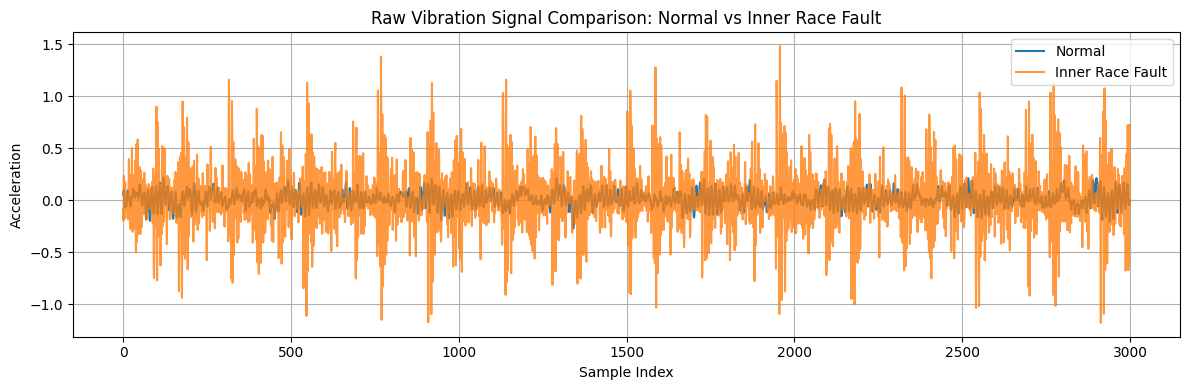

In [7]:
plot_raw_comparison(
    normal.signal,
    inner.signal,
    "Normal",
    "Inner Race Fault",
    "Raw Vibration Signal Comparison: Normal vs Inner Race Fault",
    figures_dir / "raw_normal_vs_inner.png",
)

In [ ]:
plot_raw_comparison(
    normal.signal,
    ball.signal,
    "Normal",
    "Ball Fault",
    "Raw Vibration Signal Comparison: Normal vs Ball Fault",
    figures_dir / "raw_normal_vs_ball.png",
)

In [ ]:
plot_raw_comparison(
    normal.signal,
    outer.signal,
    "Normal",
    "Outer Race Fault",
    "Raw Vibration Signal Comparison: Normal vs Outer Race Fault",
    figures_dir / "raw_normal_vs_outer.png",
)

In [ ]:
plot_fft_comparison(
    normal.signal,
    inner.signal,
    normal.sample_rate,
    "Normal",
    "Inner Race Fault",
    "FFT Comparison: Normal vs Inner Race Fault",
    figures_dir / "fft_normal_vs_inner.png",
)

In [ ]:
plot_fft_comparison(
    normal.signal,
    ball.signal,
    normal.sample_rate,
    "Normal",
    "Ball Fault",
    "FFT Comparison: Normal vs Ball Fault",
    figures_dir / "fft_normal_vs_ball.png",
)

In [ ]:
plot_signal_spectrogram(
    normal.signal,
    normal.sample_rate,
    "Spectrogram: Normal",
    figures_dir / "spectrogram_normal.png",
)

In [ ]:
plot_signal_spectrogram(
    inner.signal,
    inner.sample_rate,
    "Spectrogram: Inner Race Fault",
    figures_dir / "spectrogram_inner.png",
)

In [ ]:
plot_signal_spectrogram(
    ball.signal,
    ball.sample_rate,
    "Spectrogram: Ball Fault",
    figures_dir / "spectrogram_ball.png",
)

In [ ]:
plot_signal_spectrogram(
    outer.signal,
    outer.sample_rate,
    "Spectrogram: Outer Race Fault",
    figures_dir / "spectrogram_outer.png",
)

In [ ]:
from bcmonitor.features import extract_basic_features
import pandas as pd

In [ ]:
feature_table = pd.DataFrame(
    [
        {"label": "normal", **extract_basic_features(normal.signal, normal.sample_rate)},
        {"label": "inner_race", **extract_basic_features(inner.signal, inner.sample_rate)},
        {"label": "ball", **extract_basic_features(ball.signal, ball.sample_rate)},
        {"label": "outer_race", **extract_basic_features(outer.signal, outer.sample_rate)},
    ]
)

feature_table

In [ ]:
from bcmonitor.features import build_feature_table
import pandas as pd

In [ ]:
file_specs = [
    {"file_name": "normal_0.mat", "label": "normal"},
    {"file_name": "ir007_0.mat", "label": "inner_race"},
    {"file_name": "b007_0.mat", "label": "ball"},
    {"file_name": "or007_6_0.mat", "label": "outer_race"},
]

In [ ]:
feature_table = build_feature_table(
    file_specs=file_specs,
    sample_rate=12000.0,
    window_size=2048,
    step_size=1024,
)

feature_table.head()

In [ ]:
feature_table.shape

In [ ]:
feature_table["label"].value_counts()

In [ ]:
feature_table.groupby("label").mean(numeric_only=True)

In [ ]:
from bcmonitor.features import build_feature_table

In [ ]:
file_specs_16 = [
    {"file_name": "normal_0.mat", "label": "normal"},
    {"file_name": "normal_1.mat", "label": "normal"},
    {"file_name": "normal_2.mat", "label": "normal"},
    {"file_name": "normal_3.mat", "label": "normal"},

    {"file_name": "ir007_0.mat", "label": "inner_race"},
    {"file_name": "ir007_1.mat", "label": "inner_race"},
    {"file_name": "ir007_2.mat", "label": "inner_race"},
    {"file_name": "ir007_3.mat", "label": "inner_race"},

    {"file_name": "b007_0.mat", "label": "ball"},
    {"file_name": "b007_1.mat", "label": "ball"},
    {"file_name": "b007_2.mat", "label": "ball"},
    {"file_name": "b007_3.mat", "label": "ball"},

    {"file_name": "or007_6_0.mat", "label": "outer_race"},
    {"file_name": "or007_6_1.mat", "label": "outer_race"},
    {"file_name": "or007_6_2.mat", "label": "outer_race"},
    {"file_name": "or007_6_3.mat", "label": "outer_race"},
]

In [ ]:
feature_table_16 = build_feature_table(
    file_specs=file_specs_16,
    sample_rate=12000.0,
    window_size=2048,
    step_size=1024,
)

feature_table_16.head()

In [ ]:
feature_table_16.shape

In [ ]:
feature_table_16["label"].value_counts()

In [ ]:
feature_table_16["source_file"].value_counts().sort_index()

In [ ]:
feature_table_16.groupby("label").mean(numeric_only=True)

In [ ]:
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

feature_table_16.to_csv(processed_dir / "feature_table_16files.csv", index=False)

In [ ]:
file_counts = feature_table_16["source_file"].value_counts().sort_index()
file_counts

In [ ]:
min_windows_per_file = int(file_counts.min())
min_windows_per_file

In [ ]:
balanced_feature_table_16 = (
    feature_table_16
    .groupby("source_file", group_keys=False)
    .sample(n=min_windows_per_file, random_state=42)
    .reset_index(drop=True)
)

balanced_feature_table_16.shape

In [ ]:
balanced_feature_table_16["label"].value_counts()

In [ ]:
balanced_feature_table_16["source_file"].value_counts().sort_index()

In [ ]:
balanced_feature_table_16.to_csv(
    processed_dir / "feature_table_16files_balanced.csv",
    index=False,
)

In [ ]:
balanced_feature_table_16["load_id"] = (
    balanced_feature_table_16["source_file"]
    .str.extract(r"_(\d)\.mat$")
    .astype(int)
)

balanced_feature_table_16[["source_file", "load_id"]].drop_duplicates().sort_values("source_file")

In [ ]:
feature_columns = [
    "mean",
    "std",
    "rms",
    "peak_to_peak",
    "crest_factor",
    "shape_factor",
    "impulse_factor",
    "clearance_factor",
    "skewness",
    "kurtosis",
    "dominant_frequency",
]

In [ ]:
train_df = balanced_feature_table_16[balanced_feature_table_16["load_id"].isin([0, 1, 2])].copy()
test_df = balanced_feature_table_16[balanced_feature_table_16["load_id"] == 3].copy()

X_train = train_df[feature_columns]
y_train = train_df["label"]

X_test = test_df[feature_columns]
y_test = test_df["label"]

train_df.shape, test_df.shape

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42)),
])

logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)

accuracy_score(y_test, y_pred_logreg)

In [ ]:
print(classification_report(y_test, y_pred_logreg))

In [ ]:
confusion_matrix(y_test, y_pred_logreg)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

accuracy_score(y_test, y_pred_rf)

In [ ]:
print(classification_report(y_test, y_pred_rf))

In [ ]:
confusion_matrix(y_test, y_pred_rf)

In [ ]:
from bcmonitor.train import (
    DEFAULT_FEATURE_COLUMNS,
    split_by_load,
    build_logistic_regression_model,
    build_random_forest_model,
    fit_model,
    save_model,
)
from bcmonitor.evaluate import (
    evaluate_predictions,
    print_evaluation_summary,
    plot_confusion_matrix,
    save_feature_importance_plot,
)

In [ ]:
train_df, test_df, X_train, X_test, y_train, y_test = split_by_load(
    df=balanced_feature_table_16,
    train_loads=[0, 1, 2],
    test_loads=[3],
    feature_columns=DEFAULT_FEATURE_COLUMNS,
)

train_df.shape, test_df.shape

In [ ]:
logreg_model = build_logistic_regression_model()
logreg_model = fit_model(logreg_model, X_train, y_train)

y_pred_logreg = logreg_model.predict(X_test)
logreg_results = evaluate_predictions(y_test, y_pred_logreg)

print_evaluation_summary("Logistic Regression", logreg_results)

In [ ]:
rf_model = build_random_forest_model()
rf_model = fit_model(rf_model, X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_results = evaluate_predictions(y_test, y_pred_rf)

print_evaluation_summary("Random Forest", rf_results)

In [ ]:
labels = ["ball", "inner_race", "normal", "outer_race"]

plot_confusion_matrix(
    y_test,
    y_pred_logreg,
    labels=labels,
    title="Confusion Matrix: Logistic Regression",
    output_path=figures_dir / "confusion_matrix_logreg.png",
)

In [ ]:
plot_confusion_matrix(
    y_test,
    y_pred_rf,
    labels=labels,
    title="Confusion Matrix: Random Forest",
    output_path=figures_dir / "confusion_matrix_rf.png",
)

In [ ]:
save_feature_importance_plot(
    feature_names=DEFAULT_FEATURE_COLUMNS,
    importances=rf_model.feature_importances_,
    title="Random Forest Feature Importance",
    output_path=figures_dir / "rf_feature_importance.png",
)

In [ ]:
save_model(logreg_model, "logreg_load012_test3.joblib")
save_model(rf_model, "rf_load012_test3.joblib")